# Caps, floors and optionlet risk

Build a floating leg, price its cap and floor with Black, and reconstruct the optionlet values.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A floating-rate borrower can buy a cap to limit interest above a strike; a floor pays when the fixing falls below its strike. QuantLib represents both contracts on a dated `IborLeg`, with projection inherited from its index and discounting supplied by the pricing engine.

The notebook starts a three-year quarterly leg six months after the reference date, notional 100, Actual/360, Modified Following and zero fixing lag. It uses the illustrative dual curves, strike 4%, a flat Black optionlet volatility of 20%, and `BlackCapFloorEngine`. All reset dates are future dates. Indexed coupons are explicit so adjusted accrual periods are not silently substituted for index periods.

For each coupon, the code reads its fixing, value, maturity and payment dates, independently derives its index forward from projection discount factors, and reconstructs the Black caplet/floorlet value using the actual coupon accrual and OIS payment discount. The sum must match each QuantLib instrument. Cap minus floor must equal the discounted floating-minus-fixed coupons. A quote-based volatility sweep then shows the premium response while the contract and curves remain fixed.

Flat optionlet volatility is a constructed assumption, not a cap-volatility surface stripped from quotes. Unshifted Black requires positive forwards and strikes; normal or shifted-lognormal models need separately specified units and conventions. No smile calibration or hedge P&L is claimed. References: [caps and floors API](https://quantlib-python-docs.readthedocs.io/en/latest/instruments/caps.html) and [Black cap/floor engine](https://github.com/lballabio/QuantLib/blob/master/ql/pricingengines/capfloor/blackcapfloorengine.cpp).

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from scipy.stats import norm
with valuation_date():
    discount, projection, _ = curves()
    dh = ql.YieldTermStructureHandle(discount)
    index = ql.IborIndex('IllustrativeCap3M', ql.Period('3M'), 0, ql.USDCurrency(),
                        CAL, ql.ModifiedFollowing, False, ql.Actual360(),
                        ql.YieldTermStructureHandle(projection))
    start = CAL.advance(DATE, ql.Period('6M'))
    end = CAL.advance(start, ql.Period('3Y'))
    schedule = ql.Schedule(start, end, ql.Period('3M'), CAL, ql.ModifiedFollowing,
                           ql.ModifiedFollowing, ql.DateGeneration.Forward, False)
    leg = ql.IborLeg([100.], schedule, index, ql.Actual360(), ql.ModifiedFollowing,
                    withIndexedCoupons=True)
    strike, vol_quote = .04, ql.SimpleQuote(.20)
    engine = ql.BlackCapFloorEngine(dh, ql.QuoteHandle(vol_quote), ql.Actual365Fixed())
    cap, floor = ql.Cap(leg, [strike]), ql.Floor(leg, [strike])
    cap.setPricingEngine(engine); floor.setPricingEngine(engine)
    rows = []
    for flow in leg:
        coupon = ql.as_floating_rate_coupon(flow)
        fixing = coupon.fixingDate()
        value = index.valueDate(fixing); maturity = index.maturityDate(value)
        index_tau = index.dayCounter().yearFraction(value, maturity)
        forward = (projection.discount(value)/projection.discount(maturity)-1)/index_tau
        expiry = ql.Actual365Fixed().yearFraction(DATE, fixing)
        stddev = vol_quote.value()*np.sqrt(expiry)
        d1 = np.log(forward/strike)/stddev + stddev/2
        d2 = d1-stddev
        scale = coupon.nominal()*coupon.accrualPeriod()*discount.discount(coupon.date())
        caplet = scale*(forward*norm.cdf(d1)-strike*norm.cdf(d2))
        floorlet = scale*(strike*norm.cdf(-d2)-forward*norm.cdf(-d1))
        assert abs(forward-coupon.indexFixing()) < 1e-12
        rows.append({'payment':coupon.date().ISO(), 'forward_pct':forward*100,
                     'caplet_PV':caplet, 'floorlet_PV':floorlet,
                     'linear_coupon_PV':scale*(forward-strike)})
    optionlets = pd.DataFrame(rows)
    assert abs(optionlets.caplet_PV.sum()-cap.NPV()) < 1e-10
    assert abs(optionlets.floorlet_PV.sum()-floor.NPV()) < 1e-10
    assert abs(cap.NPV()-floor.NPV()-optionlets.linear_coupon_PV.sum()) < 1e-10
    values = []
    try:
        for vol in [.05, .10, .20, .30, .40]:
            vol_quote.setValue(vol)
            values.append({'Black_vol_pct':vol*100, 'cap_PV':cap.NPV(), 'floor_PV':floor.NPV()})
    finally:
        vol_quote.setValue(.20)
    volatility = pd.DataFrame(values)
    assert (np.diff(volatility.cap_PV) > 0).all()
    assert (np.diff(volatility.floor_PV) > 0).all()
    assert np.allclose(volatility.cap_PV-volatility.floor_PV,
                       optionlets.linear_coupon_PV.sum(), rtol=0, atol=1e-10)
    print(f'Base cap PV {cap.NPV():.6f}; floor PV {floor.NPV():.6f}; per 100 notional')
display(optionlets.round(6)); display(volatility.round(6))

Base cap PV 1.156105; floor PV 1.216387; per 100 notional


,payment,forward_pct,caplet_PV,floorlet_PV,linear_coupon_PV
0,2027-06-15,4.239421,0.092014,0.032534,0.059479
1,2027-09-15,4.239421,0.103222,0.044307,0.058915
2,2027-12-15,4.041509,0.082372,0.072358,0.010013
3,2028-03-15,4.041509,0.090608,0.080684,0.009924
4,2028-06-15,4.041735,0.098928,0.088931,0.009998
5,2028-09-15,4.041735,0.105508,0.095600,0.009908
6,2028-12-15,3.840593,0.085221,0.122338,-0.037117
7,2029-03-15,3.840388,0.089545,0.125996,-0.036451
8,2029-06-15,3.840797,0.096481,0.133332,-0.036851
9,2029-09-17,3.841205,0.103361,0.140590,-0.037230


,Black_vol_pct,cap_PV,floor_PV
0,5.0,0.316711,0.376993
1,10.0,0.585791,0.646073
2,20.0,1.156105,1.216387
3,30.0,1.729617,1.789899
4,40.0,2.296723,2.357006


## Economic relationship

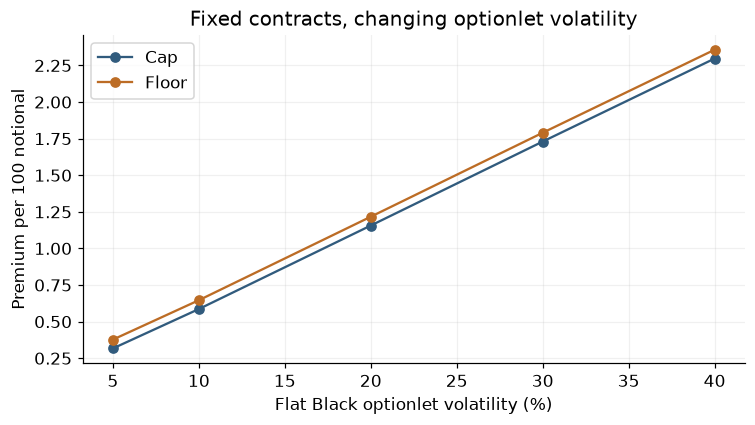

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(volatility.Black_vol_pct, volatility.cap_PV, marker='o', label='Cap', color='#315b7d')
ax.plot(volatility.Black_vol_pct, volatility.floor_PV, marker='o', label='Floor', color='#bc6c25')
ax.set(xlabel='Flat Black optionlet volatility (%)', ylabel='Premium per 100 notional',
       title='Fixed contracts, changing optionlet volatility')
ax.legend(); fig.tight_layout(); plt.show()

## Interpretation

Independent optionlet sums reproduce both prices, and cap–floor parity reconciles to the linear floating-minus-fixed leg. Raising the assumed volatility increases both premiums while leaving their difference unchanged.